# Valuación de opciones con aprendizaje estadístico
### LSM-Clásico (OLS) vs LSM-SVR (RBF) para opciones put americanas

Notebook definitivo que integra:
- La arquitectura modular por emisora y la corrección metodológica (volatilidad histórica,
  simulación bajo medida de riesgo neutral, StandardScaler antes de SVR, sin fuga temporal).
- La separación de trayectorias política/valuación para eliminar el sesgo in-sample del LSM.
- Kernel RBF como resultado central (justificado vía teorema de Mercer), con kernels
  lineal/polinomial/sigmoide como análisis de robustez.
- Backend intercambiable CPU (`sklearn`) / GPU (`cuml`, vía WSL2 + RAPIDS).
- Benchmarks adicionales: Black-Scholes, Monte Carlo (backward induction), Binomial CRR.
- Validación empírica contra precios de mercado observados (option chains reales).
- Gráficas de diagnóstico del LSM con muestreo estratificado (sin saturar de ruido).
- Exportación de tablas a LaTeX.


## 1. Dependencias

In [1]:
# Ejecutar una sola vez por ambiente
# CPU (Mac / Windows sin WSL2):
!pip install -q yfinance scikit-learn numpy pandas matplotlib mplfinance requests

# GPU (Windows + WSL2 + RAPIDS): instalar cuml siguiendo el selector de rapids.ai
# conda create -n rapids -c rapidsai -c conda-forge -c nvidia cuml=... python=3.11 cuda-version=...


## 2. Importaciones

In [2]:
import os
import json
import warnings
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import yfinance as yf
import requests
from scipy.stats import norm

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

warnings.filterwarnings('ignore')

# Estilo académico: serif + CM math, sin ticks de más, todo inline
mpl.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 110,
})
%matplotlib inline

SEED = 42
np.random.seed(SEED)


## 3. Configuración Global

`BACKEND` es el único switch entre CPU y GPU para todo el notebook. Cámbialo a `'gpu'`
únicamente en el ambiente de WSL2 con RAPIDS instalado; en cualquier otro ambiente debe
quedar en `'cpu'`.


In [3]:
BACKEND = 'gpu'  # 'cpu' (sklearn, cualquier equipo) | 'gpu' (cuml, WSL2 + RAPIDS)

if BACKEND == 'gpu':
    from cuml.svm import SVR as SVR_BACKEND
    from cuml.preprocessing import StandardScaler as SCALER_BACKEND
else:
    from sklearn.svm import SVR as SVR_BACKEND
    from sklearn.preprocessing import StandardScaler as SCALER_BACKEND

# Emisoras: ticker -> nombre para tablas/gráficas
EMISORAS = {
    'WALMEX.MX':    'Walmart de México',
    'AC.MX':        'Arca Continental',
    'CEMEXCPO.MX':  'Cemex',
    'NVDA':         'NVIDIA',
    'AAPL':         'Apple Inc.'
}
TICKERS = list(EMISORAS.keys())

# Ventana histórica para volatilidad histórica y precio spot
FECHA_FIN = datetime.today()
FECHA_INICIO = FECHA_FIN - timedelta(days=365 * 2)

# Parámetros de la opción / simulación
T = 1            # 3 meses a vencimiento (ajustar según el caso de estudio)
NUM_STEPS = 252       # pasos diarios aprox. en un trimestre
dt = T / NUM_STEPS

# Modo desarrollo (rápido, para depurar) vs producción (para resultados finales)
MODO = 'desarrollo'  # 'desarrollo' | 'produccion'
NUM_PATHS = 2_000 if MODO == 'desarrollo' else 100_000

# Razones de moneyness S0/K a evaluar (ATM = 1.00)
MONEYNESS_RATIOS = [0.75, 0.80, 0.85, 0.90, 0.95, 1.00, 1.05, 1.10, 1.15, 1.20, 1.25]

# Hiperparámetros SVR por default (se sobreescriben con calibrar_svr)
SVR_KERNEL = 'rbf'
SVR_C = 100.0
SVR_GAMMA = 'scale'
SVR_EPSILON = 0.1

OPTION_TYPE = 'puts'


## 4. Tasa libre de riesgo, descarga de datos y estadísticos descriptivos

In [4]:
def obtener_tasa_libre_riesgo(default=0.045):
    """Tasa libre de riesgo (CETES 28d vía Banxico si hay token; si no, default)."""
    token = os.environ.get('BANXICO_TOKEN')
    if not token:
        return default
    try:
        url = ("https://www.banxico.org.mx/SieAPIRest/service/v1/series/SF43936/datos/oportuno"
               f"?token={token}")
        resp = requests.get(url, timeout=5).json()
        valor = float(resp['bmx']['series'][0]['datos'][-1]['dato'])
        return valor / 100.0
    except Exception:
        return default


def descargar_datos(ticker, fecha_inicio, fecha_fin):
    """Descarga histórico y calcula volatilidad histórica anualizada (sin look-ahead)."""
    df = yf.download(ticker, start=fecha_inicio, end=fecha_fin, progress=False)
    if df is None or df.empty:
        raise ValueError(f"Sin datos para {ticker}, revisa el ticker o la ventana de fechas.")
    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
    sigma = df['log_ret'].std() * np.sqrt(252)
    S0 = float(df['Close'].iloc[-1])
    return df, float(sigma), S0


r_libre = obtener_tasa_libre_riesgo()
PARAMS = {}
DATOS = {}

for tk in TICKERS:
    df_tk, sigma_tk, S0_tk = descargar_datos(tk, FECHA_INICIO, FECHA_FIN)
    DATOS[tk] = df_tk
    PARAMS[tk] = {'S0': S0_tk, 'sigma': sigma_tk, 'r': r_libre, 'nombre': EMISORAS[tk]}

pd.DataFrame(PARAMS).T

,S0,sigma,r,nombre
WALMEX.MX,45.549999,0.263667,0.0625,Walmart de México
AC.MX,195.869995,0.238964,0.0625,Arca Continental
CEMEXCPO.MX,18.129999,0.338538,0.0625,Cemex
NVDA,218.289993,0.442956,0.0625,NVIDIA
AAPL,332.269989,0.288832,0.0625,Apple Inc.


## 5. Gráficas Exploratorias

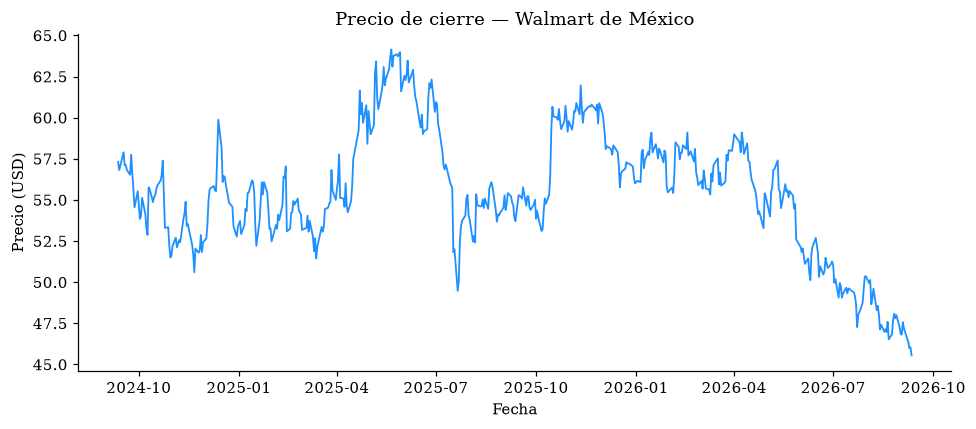

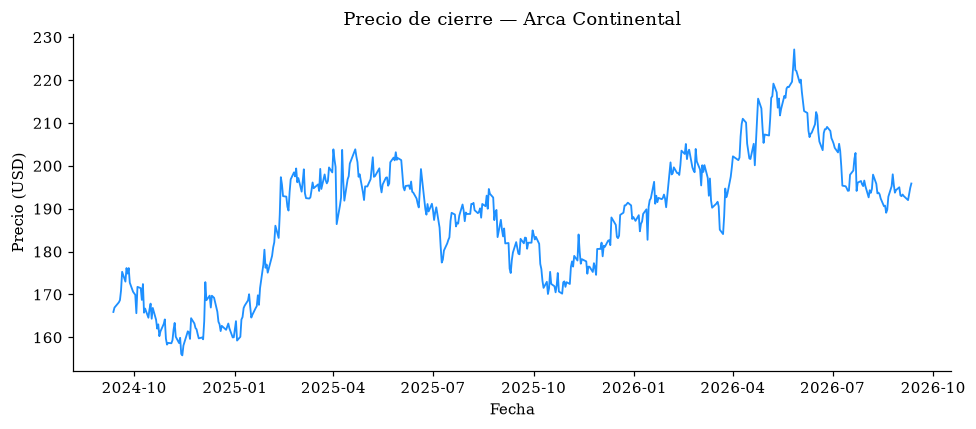

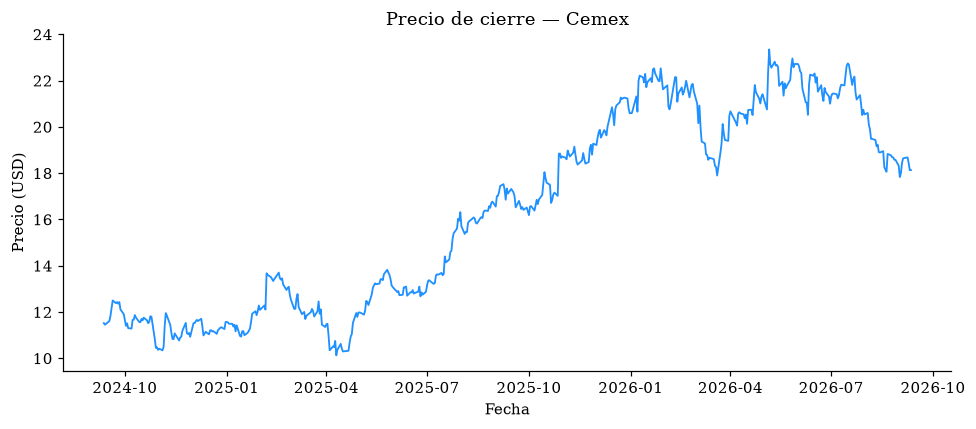

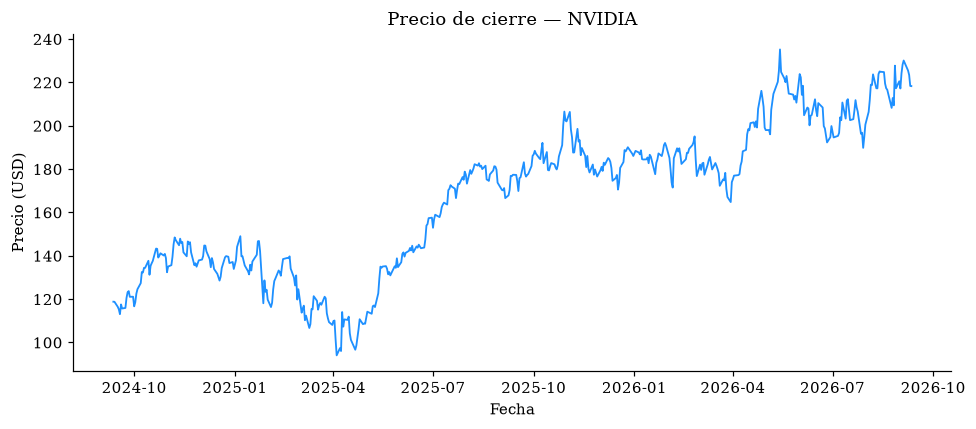

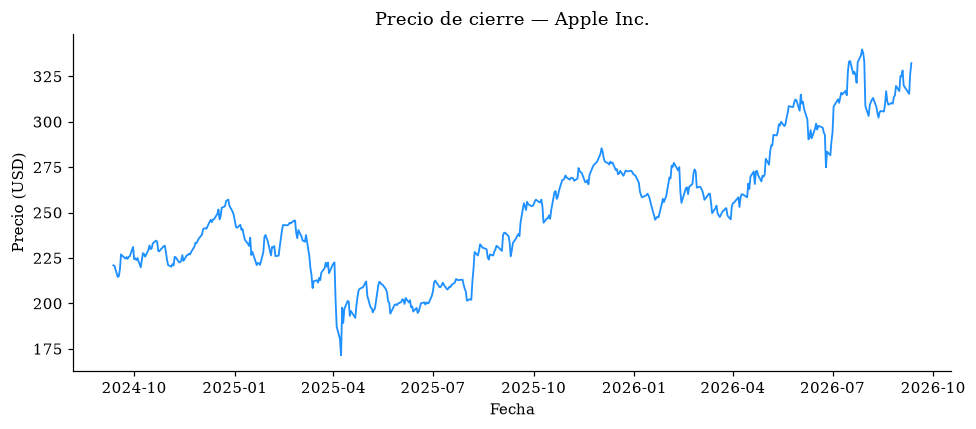

In [5]:
def graficar_precio_historico(ticker):
    df = DATOS[ticker]
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(df.index, df['Close'], color='#1E90FF', lw=1.2)
    ax.set_title(f"Precio de cierre — {EMISORAS[ticker]}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Precio (USD)")
    plt.tight_layout()
    plt.show()

for tk in TICKERS:
    graficar_precio_historico(tk)


## 6. Distribución de Rendimientos

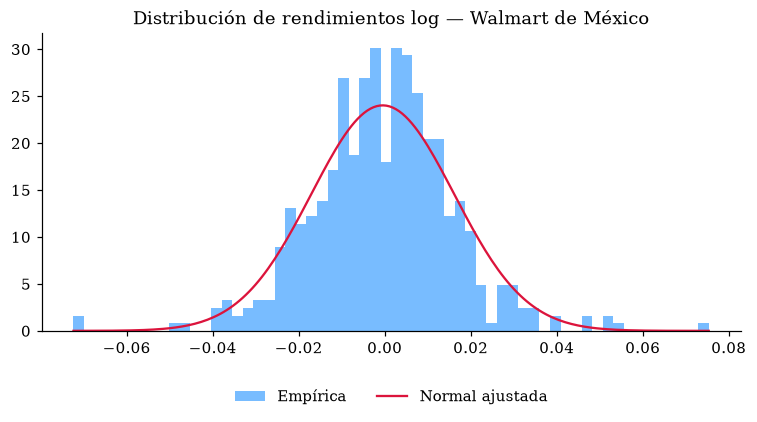

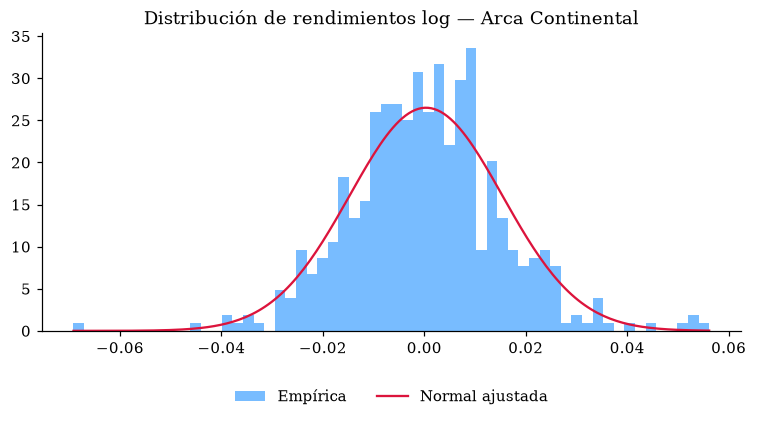

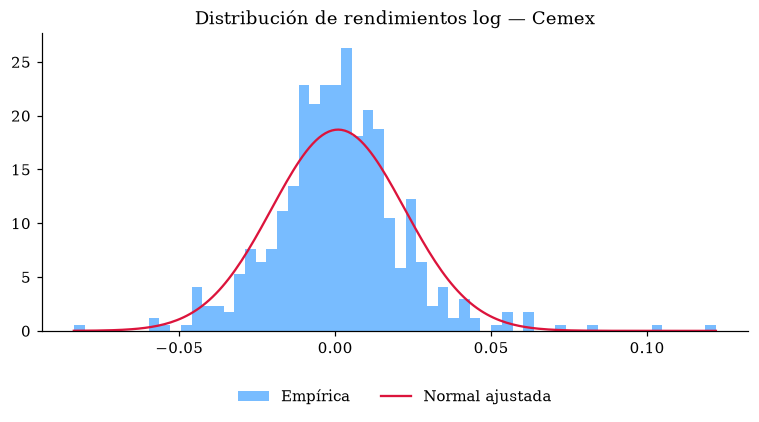

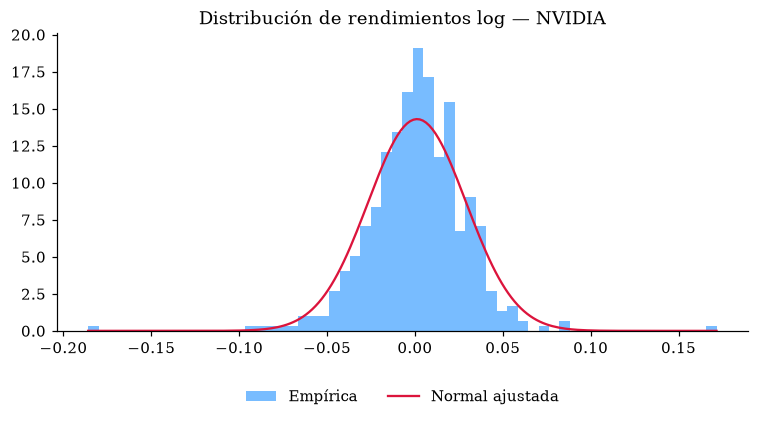

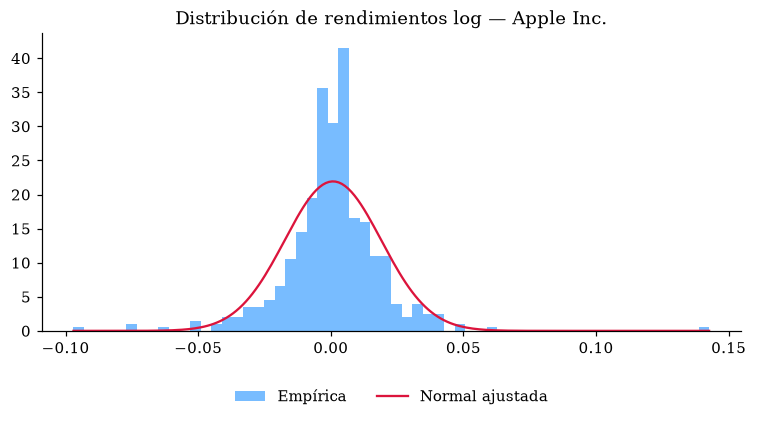

In [6]:
def graficar_distribucion_rendimientos(ticker):
    log_ret = DATOS[ticker]['log_ret'].dropna()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(log_ret, bins=60, density=True, color='#1E90FF', alpha=0.6, label='Empírica')
    x = np.linspace(log_ret.min(), log_ret.max(), 200)
    ax.plot(x, norm.pdf(x, log_ret.mean(), log_ret.std()), color='#DC143C', lw=1.5,
            label='Normal ajustada')
    ax.set_title(f"Distribución de rendimientos log — {EMISORAS[ticker]}")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()

for tk in TICKERS:
    graficar_distribucion_rendimientos(tk)


## 7. Simulación GBM bajo medida de riesgo neutral (Q)

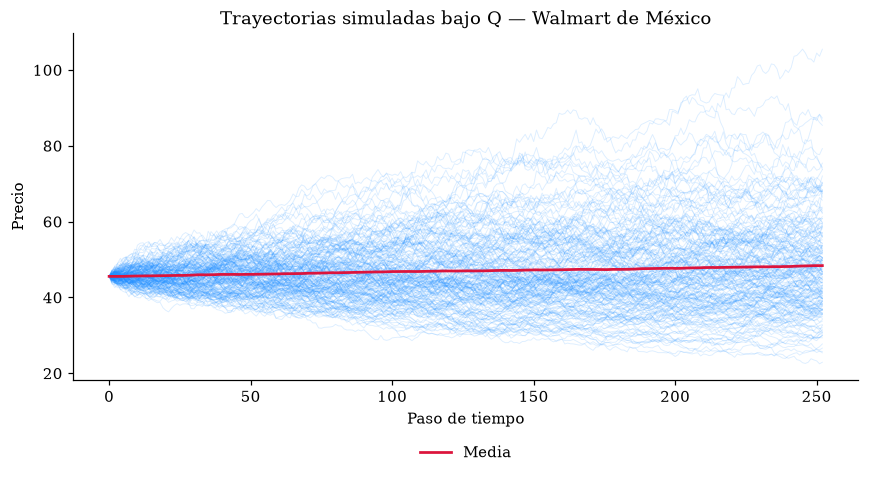

In [7]:
def simulate_gbm_rn(r, sigma, S0, T, dt, num_paths, seed=None):
    """Trayectorias GBM bajo Q: drift = r (no mu), descuento correcto por paso."""
    rng = np.random.default_rng(seed)
    num_steps = int(round(T / dt)) + 1
    Z = rng.standard_normal((num_paths, num_steps - 1))
    incrementos = (r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z
    log_paths = np.concatenate([np.zeros((num_paths, 1)), np.cumsum(incrementos, axis=1)], axis=1)
    return S0 * np.exp(log_paths)


def graficar_trayectorias(paths, ticker, n_mostrar=200):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    idx = np.random.choice(paths.shape[0], size=min(n_mostrar, paths.shape[0]), replace=False)
    ax.plot(paths[idx].T, color='#1E90FF', alpha=0.15, lw=0.6)
    ax.plot(paths.mean(axis=0), color='#DC143C', lw=1.8, label='Media')
    ax.set_title(f"Trayectorias simuladas bajo Q — {EMISORAS[ticker]}")
    ax.set_xlabel("Paso de tiempo")
    ax.set_ylabel("Precio")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)
    plt.tight_layout()
    plt.show()

tk_demo = TICKERS[0]
p_demo = PARAMS[tk_demo]
paths_demo = simulate_gbm_rn(p_demo['r'], p_demo['sigma'], p_demo['S0'], T, dt, 2000, seed=SEED)
graficar_trayectorias(paths_demo, tk_demo)


## 8. Trayectorias de política y de valuación

`split_paths=True` simula el doble de trayectorias y separa un conjunto para **estimar
la política de ejercicio** (ajustar la regresión) de otro, independiente, para **valuar**
aplicando esa política ya fija. Esto elimina el sesgo in-sample documentado en la
literatura de Longstaff-Schwartz. `split_paths=False` reproduce el enfoque naive
(mismas trayectorias para ambas cosas) y se conserva como caso de comparación de robustez.


In [8]:
def preparar_trayectorias(r, sigma, S0, T, dt, num_paths, seed, split_paths=True):
    """
    split_paths=True  -> simula 2*num_paths, parte en política/valuación (independientes)
    split_paths=False -> simula num_paths, mismo array para ambas (enfoque naive)
    """
    if split_paths:
        paths_full = simulate_gbm_rn(r, sigma, S0, T, dt, num_paths * 2, seed=seed)
        paths_pol = paths_full[:num_paths]
        paths_val = paths_full[num_paths:]
    else:
        paths_pol = simulate_gbm_rn(r, sigma, S0, T, dt, num_paths, seed=seed)
        paths_val = paths_pol  # mismo objeto -> activa el atajo interno en lsm_*

    return paths_pol, paths_val


## 9. LSM-Clásico (OLS Polinomial)

In [9]:
def lsm_clasico(paths_pol: np.ndarray, paths_val: np.ndarray,
                 K: float, r: float, T: float,
                 option_type: str = 'puts',
                 poly_degree: int = 3,
                 min_itm: int = 10,
                 min_exercise_step: int = 2,
                 track_decisions: bool = False) -> dict:
    ot = option_type.lower()
    num_steps = paths_pol.shape[1]
    dt_s = T / (num_steps - 1)
    disc = np.exp(-r * dt_s)
    mismo_set = paths_pol is paths_val

    def payoff(S):
        return np.maximum(K - S, 0.0) if ot == 'puts' else np.maximum(S - K, 0.0)

    num_pol = paths_pol.shape[0]
    num_val = paths_val.shape[0]

    cash_flows_pol = payoff(paths_pol).copy()
    activo_pol = np.ones(num_pol, dtype=bool)

    activo_val = np.ones(num_val, dtype=bool)
    stopping = np.full(num_val, num_steps - 1, dtype=int)
    exercise_value_val = payoff(paths_val[:, -1]).copy()

    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=poly_degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg',    LinearRegression())
    ])
    decisiones = {} if track_decisions else None

    for t in range(num_steps - 2, 0, -1):
        cash_flows_pol[activo_pol, t] = cash_flows_pol[activo_pol, t + 1] * disc

        if t < min_exercise_step:
            if track_decisions:
                itm_early = activo_val & ((paths_val[:, t] < K) if ot == 'puts' else (paths_val[:, t] > K))  # <-- FIX
                decisiones[t] = {'exercise_prices': [],
                                  'continuation_prices': paths_val[itm_early, t].tolist()}  # <-- FIX
            continue

        itm_pol = activo_pol & ((paths_pol[:, t] < K) if ot == 'puts' else (paths_pol[:, t] > K))
        ajustado = itm_pol.sum() >= max(poly_degree + 1, min_itm)
        intrinsic_pol = payoff(paths_pol[:, t])

        idx_itm_pol = np.where(itm_pol)[0]
        if ajustado:
            X_pol = paths_pol[idx_itm_pol, t].reshape(-1, 1)
            Y_pol = cash_flows_pol[idx_itm_pol, t + 1] * disc
            pipe.fit(X_pol, Y_pol)
            cont_pred = pipe.predict(X_pol)
            ejerce_sub = intrinsic_pol[idx_itm_pol] > cont_pred
        elif len(idx_itm_pol) > 0:
            ejerce_sub = np.zeros(len(idx_itm_pol), dtype=bool)
        else:
            ejerce_sub = np.array([], dtype=bool)

        idx_ejerce_pol = idx_itm_pol[ejerce_sub]
        cash_flows_pol[idx_ejerce_pol, t] = intrinsic_pol[idx_ejerce_pol]
        activo_pol[idx_ejerce_pol] = False

        if mismo_set:
            idx_ejerce_val = idx_ejerce_pol
            cont_prices_plot = paths_val[idx_itm_pol[~ejerce_sub], t] if len(idx_itm_pol) else np.array([])
        else:
            itm_val = activo_val & ((paths_val[:, t] < K) if ot == 'puts' else (paths_val[:, t] > K))
            idx_itm_val = np.where(itm_val)[0]
            intrinsic_val = payoff(paths_val[:, t])
            if ajustado and len(idx_itm_val) > 0:
                X_val = paths_val[idx_itm_val, t].reshape(-1, 1)
                cont_val_pred = pipe.predict(X_val)
                ejerce_val_sub = intrinsic_val[idx_itm_val] > cont_val_pred
            elif len(idx_itm_val) > 0:
                ejerce_val_sub = np.zeros(len(idx_itm_val), dtype=bool)
            else:
                ejerce_val_sub = np.array([], dtype=bool)
            idx_ejerce_val = idx_itm_val[ejerce_val_sub]
            cont_prices_plot = paths_val[idx_itm_val[~ejerce_val_sub], t] if len(idx_itm_val) else np.array([])

        stopping[idx_ejerce_val] = t
        exercise_value_val[idx_ejerce_val] = payoff(paths_val[idx_ejerce_val, t])
        activo_val[idx_ejerce_val] = False

        if track_decisions:
            decisiones[t] = {
                'exercise_prices': paths_val[idx_ejerce_val, t].tolist(),
                'continuation_prices': cont_prices_plot.tolist(),
            }

    pv = exercise_value_val * np.exp(-r * dt_s * stopping)
    return {'precio': float(pv.mean()), 'std': float(pv.std(ddof=1)),
            'stopping': stopping, 'pv': pv, 'decisiones': decisiones}

## 10. LSM-SVR (kernel/backend intercambiables)

RBF es el resultado central de la tesis (aproximador universal vía teorema de Mercer,
no requiere declarar a priori la forma funcional del valor de continuación como sí lo
exige el grado polinomial en LSM-Clásico). Los demás kernels (`linear`, `poly`, `sigmoid`)
se usan únicamente en la sección de robustez.


In [10]:
def lsm_svr(paths_pol: np.ndarray, paths_val: np.ndarray,
            K: float, r: float, T: float,
            option_type: str = 'puts',
            kernel: str = SVR_KERNEL, C: float = SVR_C, gamma=SVR_GAMMA, epsilon: float = SVR_EPSILON,
            backend: str = BACKEND,
            min_itm: int = 10,
            min_exercise_step: int = 2,
            track_decisions: bool = False) -> dict:
    if backend == 'gpu':
        from cuml.svm import SVR as SVR_
        from cuml.preprocessing import StandardScaler as Scaler_
    else:
        from sklearn.svm import SVR as SVR_
        from sklearn.preprocessing import StandardScaler as Scaler_

    ot = option_type.lower()
    num_steps = paths_pol.shape[1]
    dt_s = T / (num_steps - 1)
    disc = np.exp(-r * dt_s)
    mismo_set = paths_pol is paths_val

    def payoff(S):
        return np.maximum(K - S, 0.0) if ot == 'puts' else np.maximum(S - K, 0.0)

    num_pol = paths_pol.shape[0]
    num_val = paths_val.shape[0]

    cash_flows_pol = np.zeros(num_pol)
    cash_flows_pol[:] = payoff(paths_pol[:, -1])
    activo_pol = np.ones(num_pol, dtype=bool)

    activo_val = np.ones(num_val, dtype=bool)
    stopping = np.full(num_val, num_steps - 1, dtype=int)
    exercise_value_val = payoff(paths_val[:, -1]).copy()

    decisiones = {} if track_decisions else None

    for t in range(num_steps - 2, 0, -1):
        cash_flows_pol[activo_pol] = cash_flows_pol[activo_pol] * disc

        if t < min_exercise_step:
            if track_decisions:
                itm_early = activo_val & ((paths_val[:, t] < K) if ot == 'puts' else (paths_val[:, t] > K))  # <-- FIX
                decisiones[t] = {'exercise_prices': [],
                                  'continuation_prices': paths_val[itm_early, t].tolist()}  # <-- FIX
            continue

        itm_pol = activo_pol & ((paths_pol[:, t] < K) if ot == 'puts' else (paths_pol[:, t] > K))
        ajustado = itm_pol.sum() >= max(3, min_itm)
        intrinsic_pol = payoff(paths_pol[:, t])
        idx_itm_pol = np.where(itm_pol)[0]

        if ajustado:
            X_pol = paths_pol[idx_itm_pol, t].reshape(-1, 1)
            Y_pol = cash_flows_pol[idx_itm_pol]
            scaler = Scaler_()
            X_pol_s = scaler.fit_transform(X_pol)
            modelo = SVR_(kernel=kernel, C=C, gamma=gamma, epsilon=epsilon)
            modelo.fit(X_pol_s, Y_pol)
            cont_pred = modelo.predict(X_pol_s)
            ejerce_sub = intrinsic_pol[idx_itm_pol] > cont_pred
        elif len(idx_itm_pol) > 0:
            ejerce_sub = np.zeros(len(idx_itm_pol), dtype=bool)
        else:
            ejerce_sub = np.array([], dtype=bool)

        idx_ejerce_pol = idx_itm_pol[ejerce_sub]
        cash_flows_pol[idx_ejerce_pol] = intrinsic_pol[idx_ejerce_pol]
        activo_pol[idx_ejerce_pol] = False

        if mismo_set:
            idx_ejerce_val = idx_ejerce_pol
            cont_prices_plot = paths_val[idx_itm_pol[~ejerce_sub], t] if len(idx_itm_pol) else np.array([])
        else:
            itm_val = activo_val & ((paths_val[:, t] < K) if ot == 'puts' else (paths_val[:, t] > K))
            idx_itm_val = np.where(itm_val)[0]
            intrinsic_val = payoff(paths_val[:, t])
            if ajustado and len(idx_itm_val) > 0:
                X_val_s = scaler.transform(paths_val[idx_itm_val, t].reshape(-1, 1))
                cont_val_pred = modelo.predict(X_val_s)
                ejerce_val_sub = intrinsic_val[idx_itm_val] > cont_val_pred
            elif len(idx_itm_val) > 0:
                ejerce_val_sub = np.zeros(len(idx_itm_val), dtype=bool)
            else:
                ejerce_val_sub = np.array([], dtype=bool)
            idx_ejerce_val = idx_itm_val[ejerce_val_sub]
            cont_prices_plot = paths_val[idx_itm_val[~ejerce_val_sub], t] if len(idx_itm_val) else np.array([])

        stopping[idx_ejerce_val] = t
        exercise_value_val[idx_ejerce_val] = payoff(paths_val[idx_ejerce_val, t])
        activo_val[idx_ejerce_val] = False

        if track_decisions:
            decisiones[t] = {
                'exercise_prices': paths_val[idx_ejerce_val, t].tolist(),
                'continuation_prices': cont_prices_plot.tolist(),
            }

    pv = exercise_value_val * np.exp(-r * dt_s * stopping)
    return {'precio': float(pv.mean()), 'std': float(pv.std(ddof=1)),
            'stopping': stopping, 'pv': pv, 'decisiones': decisiones}

## 11. Evidencia del sesgo in-sample vs out-of-sample

Corrida única, sobre un solo emisor y strike ATM, comparando el enfoque naive
(`split_paths=False`) contra el correcto (`split_paths=True`). Se espera que el
precio in-sample sea igual o mayor al out-of-sample.


In [11]:
def comparar_sesgo_insample(ticker, params, num_paths, T, dt, seed,
                             kernel=SVR_KERNEL, backend=BACKEND):
    p = params[ticker]
    resultados = {}
    for split in [False, True]:
        pol, val = preparar_trayectorias(p['r'], p['sigma'], p['S0'], T, dt,
                                          num_paths, seed, split_paths=split)
        res = lsm_svr(pol, val, K=p['S0'], r=p['r'], T=T,
                       kernel=kernel, backend=backend)
        etiqueta = 'Out-of-sample (correcto)' if split else 'In-sample (naive)'
        resultados[etiqueta] = {'precio': res['precio'], 'std': res['std']}
    return pd.DataFrame(resultados).T


# Prueba rápida — correr primero con NUM_PATHS chico antes de ir a producción
ticker_prueba = TICKERS[0]
df_sesgo = comparar_sesgo_insample(
    ticker_prueba, PARAMS, num_paths=min(NUM_PATHS, 2000), T=T, dt=dt, seed=SEED,
    kernel=SVR_KERNEL, backend=BACKEND
)
print(f"=== Sesgo in-sample vs out-of-sample — {EMISORAS[ticker_prueba]} ===")
df_sesgo


=== Sesgo in-sample vs out-of-sample — Walmart de México ===


,precio,std
In-sample (naive),3.648306,4.756526
Out-of-sample (correcto),3.672128,4.675816


## 12. Calibración de hiperparámetros SVR (una vez por emisora)

Se calibra `(kernel, C, gamma, epsilon)` **una sola vez por emisora**, con un conjunto de
validación separado del que se usa para el pricing final (evita la fuga de información que
se tendría si se calibrara en cada paso del backward induction). Como criterio de
descarte se usa la cota teórica: el precio de la put americana debe ser mayor o igual al
precio europeo de Black-Scholes; cualquier combinación que la viole se descarta.


In [12]:
def black_scholes_put(S0, K, r, sigma, T):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S0 * norm.cdf(-d1)


def calibrar_svr(ticker, params, T, dt, num_paths_calib, seed,
                  kernels=('rbf',), C_grid=(10, 50, 100, 500),
                  gamma_grid=('scale', 0.01, 0.1),
                  epsilon_grid=(0.01, 0.1, 0.5),
                  backend=BACKEND):
    """
    Calibra sobre una malla independiente (seed distinta) y descarta combinaciones
    que violen el piso teórico BS-europea. Selecciona la que da el precio más
    cercano al mejor candidato entre las que pasan el filtro (se reporta también
    el detalle completo para justificar la elección en la tesis).
    """
    p = params[ticker]
    K = p['S0']  # ATM para la calibración, representativo
    piso_bs = black_scholes_put(p['S0'], K, p['r'], p['sigma'], T)

    pol_calib, val_calib = preparar_trayectorias(
        p['r'], p['sigma'], p['S0'], T, dt, num_paths_calib, seed=seed + 999, split_paths=True
    )

    filas = []
    for kernel in kernels:
        for C in C_grid:
            for gamma in gamma_grid:
                for epsilon in epsilon_grid:
                    res = lsm_svr(pol_calib, val_calib, K=K, r=p['r'], T=T,
                                   kernel=kernel, C=C, gamma=gamma, epsilon=epsilon,
                                   backend=backend)
                    cumple_piso = res['precio'] >= piso_bs * 0.98  # tolerancia numérica
                    filas.append({
                        'kernel': kernel, 'C': C, 'gamma': gamma, 'epsilon': epsilon,
                        'precio': res['precio'], 'std': res['std'], 'cumple_piso': cumple_piso
                    })

    df_grid = pd.DataFrame(filas)
    validos = df_grid[df_grid['cumple_piso']]
    tabla_ordenada = (validos if len(validos) > 0 else df_grid).sort_values('std')
    mejor = tabla_ordenada.iloc[0].to_dict()
    return mejor, df_grid, piso_bs


## 13. Benchmarks: Black-Scholes, Monte Carlo (backward induction) y Binomial CRR

In [13]:
def monte_carlo_backward(paths, K, r, T, option_type='puts'):
    """Cota de referencia vía backward induction exacto sobre malla de tiempos discreta."""
    ot = option_type.lower()
    num_steps = paths.shape[1]
    dt_s = T / (num_steps - 1)

    def payoff(S):
        return np.maximum(K - S, 0.0) if ot == 'puts' else np.maximum(S - K, 0.0)

    valor = payoff(paths[:, -1])
    for t in range(num_steps - 2, -1, -1):
        valor = np.maximum(payoff(paths[:, t]), valor * np.exp(-r * dt_s))
    return float(valor.mean())


def binomial_crr(S0, K, r, sigma, T, option_type='puts', n_pasos=500):
    """Árbol binomial Cox-Ross-Rubinstein para la put/call americana."""
    dt_b = T / n_pasos
    u = np.exp(sigma * np.sqrt(dt_b))
    d = 1 / u
    p = (np.exp(r * dt_b) - d) / (u - d)
    disc = np.exp(-r * dt_b)

    precios = S0 * u ** np.arange(n_pasos, -1, -1) * d ** np.arange(0, n_pasos + 1)
    if option_type.lower() == 'puts':
        valores = np.maximum(K - precios, 0.0)
    else:
        valores = np.maximum(precios - K, 0.0)

    for i in range(n_pasos - 1, -1, -1):
        precios = S0 * u ** np.arange(i, -1, -1) * d ** np.arange(0, i + 1)
        continuacion = disc * (p * valores[:-1] + (1 - p) * valores[1:])
        if option_type.lower() == 'puts':
            intrinsico = np.maximum(K - precios, 0.0)
        else:
            intrinsico = np.maximum(precios - K, 0.0)
        valores = np.maximum(intrinsico, continuacion)

    return float(valores[0])


## 14. Análisis de moneyness (con números aleatorios comunes)

Las trayectorias del subyacente no dependen del strike, así que se simulan **una sola vez
por emisora** y se reutilizan para las 11 razones de moneyness — técnica de reducción de
varianza (common random numbers): ahorra 11x de simulación y hace que las diferencias
observadas entre ratios sean atribuibles al efecto de moneyness, no a ruido aleatorio
distinto en cada corrida.


In [14]:
def analizar_moneyness(ticker, params, moneyness_ratios, T, dt, num_paths, seed,
                        kernel=SVR_KERNEL, C=SVR_C, gamma=SVR_GAMMA, epsilon=SVR_EPSILON,
                        backend=BACKEND, split_paths=True, incluir_benchmarks=True):
    p = params[ticker]
    # Trayectorias simuladas UNA sola vez, reutilizadas para todos los ratios
    paths_pol, paths_val = preparar_trayectorias(
        p['r'], p['sigma'], p['S0'], T, dt, num_paths, seed, split_paths=split_paths
    )

    filas = []
    for ratio in moneyness_ratios:
        K = p['S0'] / ratio
        res_cls = lsm_clasico(paths_pol, paths_val, K=K, r=p['r'], T=T)
        res_svr = lsm_svr(paths_pol, paths_val, K=K, r=p['r'], T=T,
                           kernel=kernel, C=C, gamma=gamma, epsilon=epsilon, backend=backend)
        fila = {
            'ticker': ticker, 'moneyness': ratio, 'K': K,
            'LSM_Clasico': res_cls['precio'], 'LSM_Clasico_std': res_cls['std'],
            'LSM_SVR': res_svr['precio'], 'LSM_SVR_std': res_svr['std'],
        }
        if incluir_benchmarks:
            fila['Black_Scholes'] = black_scholes_put(p['S0'], K, p['r'], p['sigma'], T)
            fila['Monte_Carlo'] = monte_carlo_backward(paths_val, K, p['r'], T)
            fila['Binomial_CRR'] = binomial_crr(p['S0'], K, p['r'], p['sigma'], T)
        filas.append(fila)

    return pd.DataFrame(filas), paths_pol, paths_val


resultados_moneyness = {}
paths_por_emisora = {}
for tk in TICKERS:
    df_m, pol_tk, val_tk = analizar_moneyness(
        tk, PARAMS, MONEYNESS_RATIOS, T, dt, NUM_PATHS, SEED,
        kernel=SVR_KERNEL, backend=BACKEND, split_paths=True
    )
    resultados_moneyness[tk] = df_m
    paths_por_emisora[tk] = {'pol': pol_tk, 'val': val_tk}

resultados_moneyness[TICKERS[0]]


,ticker,moneyness,K,LSM_Clasico,LSM_Clasico_std,LSM_SVR,LSM_SVR_std,Black_Scholes,Monte_Carlo,Binomial_CRR
0,WALMEX.MX,0.75,60.733332,13.173858,9.054693,13.107953,9.189064,12.963486,21.870323,15.183333
1,WALMEX.MX,0.80,56.937499,10.442160,8.069620,10.328370,8.227611,10.089994,18.176392,11.576475
2,WALMEX.MX,0.85,53.588234,8.161246,7.151354,8.085848,7.229097,7.779583,14.918092,8.776043
3,WALMEX.MX,0.90,50.611110,6.325138,6.279483,6.234739,6.347749,5.943420,12.022610,6.614422
4,WALMEX.MX,0.95,47.947368,4.892397,5.431433,4.849849,5.456367,4.501303,9.432654,4.952338
5,WALMEX.MX,1.00,45.549999,3.633485,4.649832,3.672128,4.675816,3.381619,7.102340,3.683842
6,WALMEX.MX,1.05,43.380952,2.714504,3.993034,2.761224,3.990070,2.521672,5.219260,2.725381
7,WALMEX.MX,1.10,41.409090,1.994405,3.397296,2.025029,3.364231,1.867821,3.799317,2.004744
8,WALMEX.MX,1.15,39.608695,1.469464,2.812300,1.476982,2.842604,1.375208,2.743780,1.467819
9,WALMEX.MX,1.20,37.958333,1.036731,2.348012,1.055301,2.378087,1.007124,1.970699,1.070580


## 15. Gráficas comparativas por moneyness

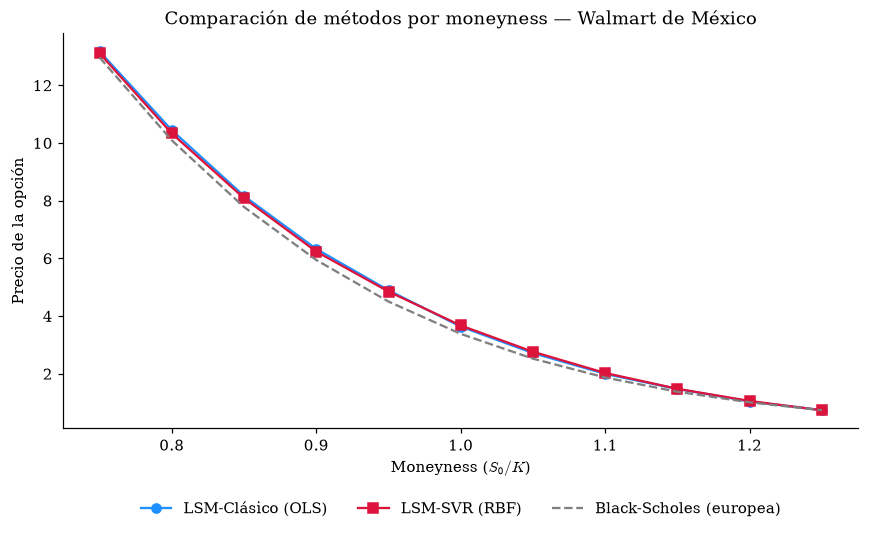

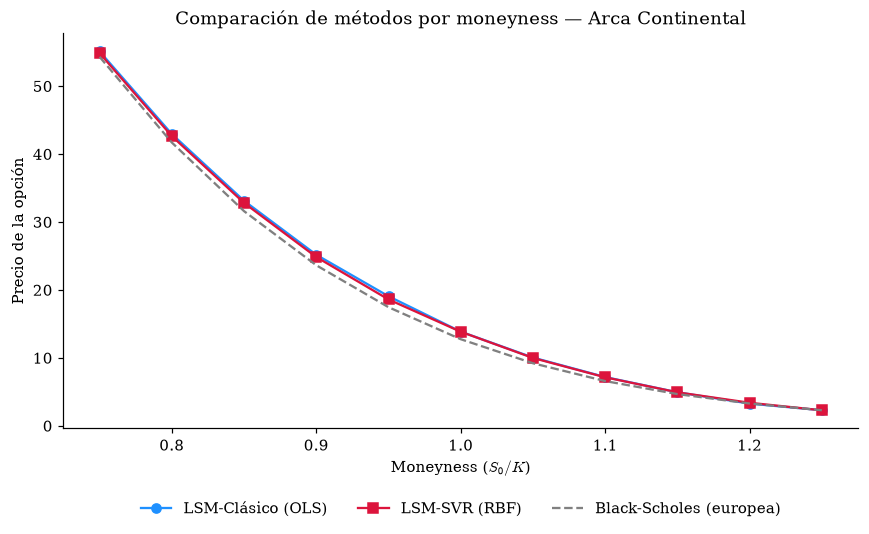

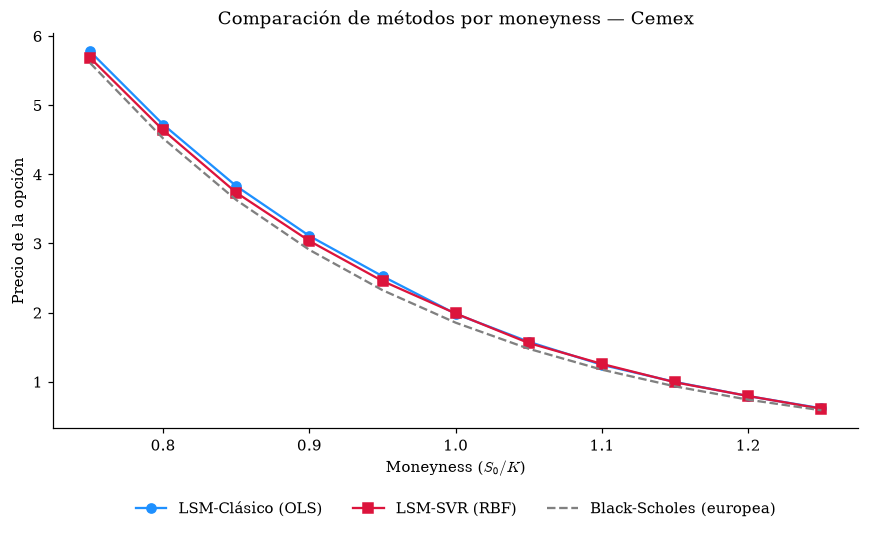

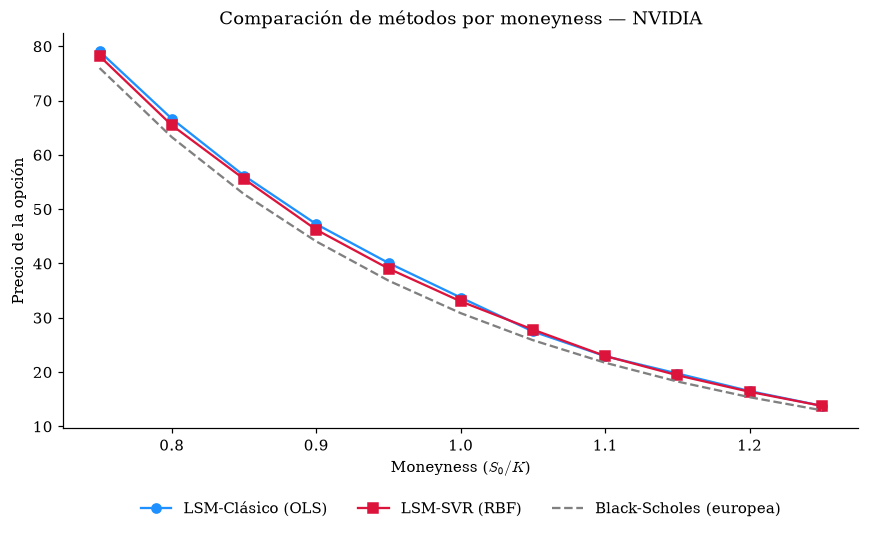

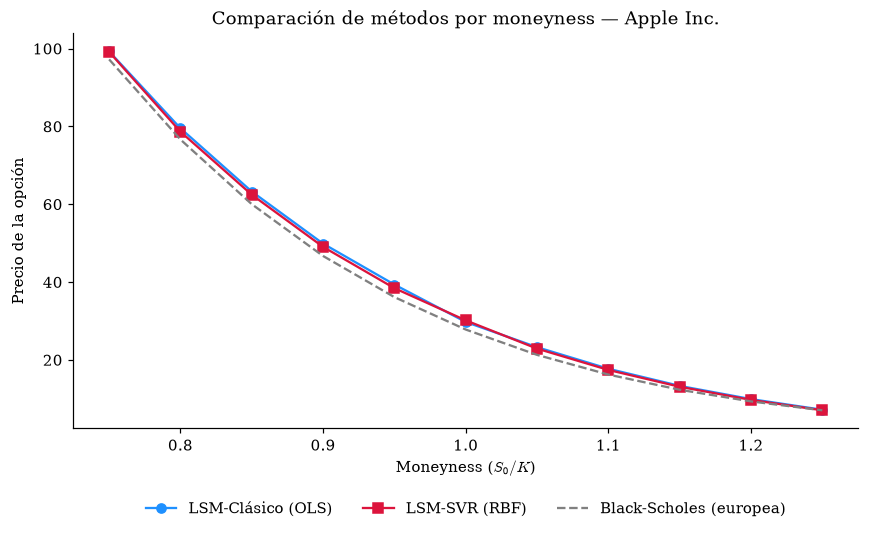

In [15]:
def graficar_comparacion_moneyness(ticker):
    df = resultados_moneyness[ticker]
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(df['moneyness'], df['LSM_Clasico'], 'o-', color='#1E90FF', label='LSM-Clásico (OLS)')
    ax.plot(df['moneyness'], df['LSM_SVR'], 's-', color='#DC143C', label='LSM-SVR (RBF)')
    ax.plot(df['moneyness'], df['Black_Scholes'], '--', color='gray', label='Black-Scholes (europea)')
    ax.set_xlabel(r'Moneyness ($S_0/K$)')
    ax.set_ylabel('Precio de la opción')
    ax.set_title(f'Comparación de métodos por moneyness — {EMISORAS[ticker]}')
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()

for tk in TICKERS:
    graficar_comparacion_moneyness(tk)


## 16. Gráficas de diagnóstico LSM (muestreo estratificado)

Para no saturar de ruido, "Ejercicio vs. Continuación" y "Trayectorias con primer
ejercicio" usan una muestra estratificada de ~15-20 trayectorias por cuantiles del
tiempo de primer ejercicio (`stopping`), no una muestra puramente aleatoria. El
espagueti general y el boxplot sí usan la población completa.


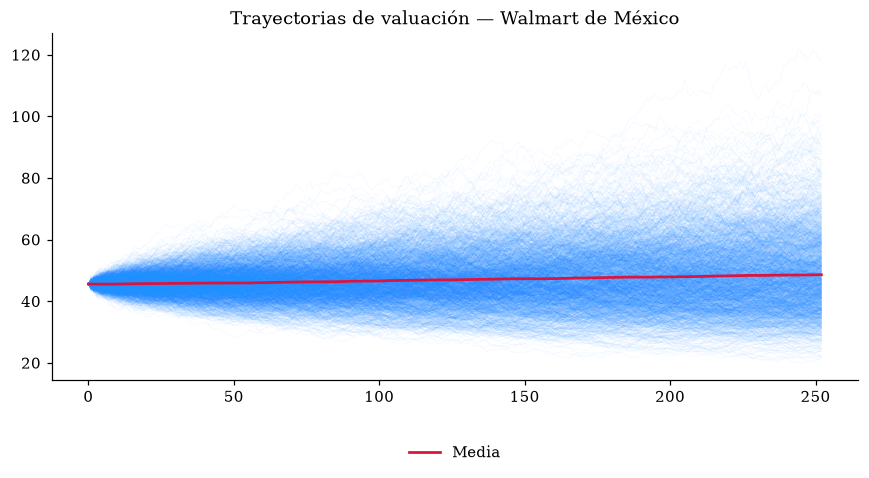

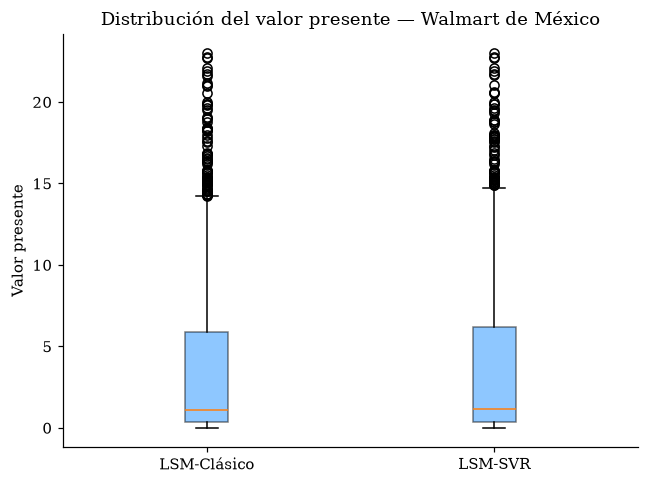

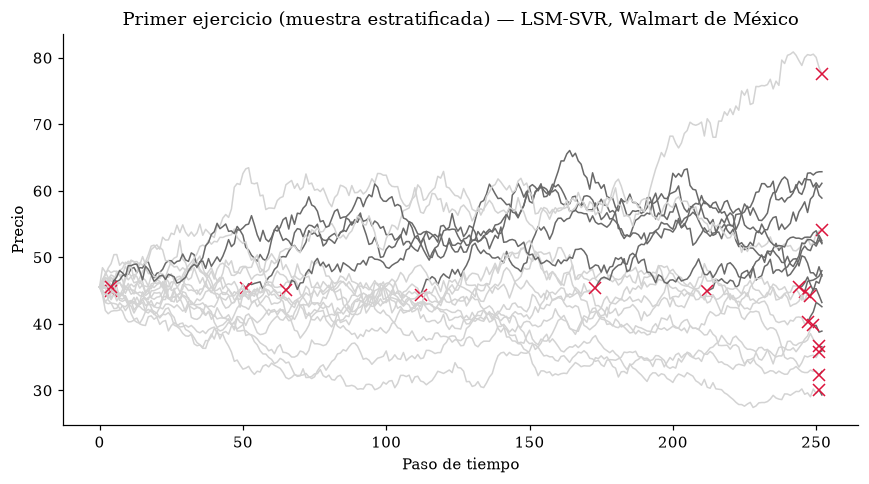

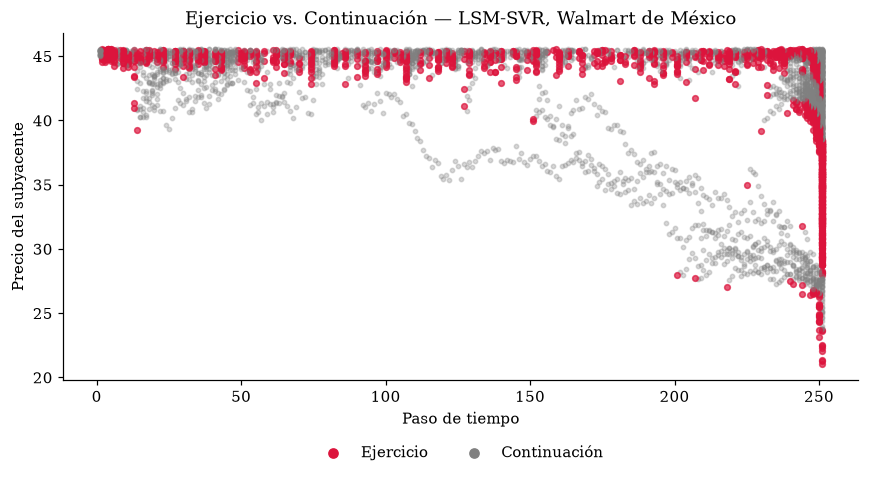

In [16]:
def muestra_estratificada(stopping, n=18, n_estratos=6):
    """Selecciona trayectorias representativas por cuantiles de stopping time."""
    cuantiles = np.linspace(0, 1, n_estratos + 1)
    cortes = np.quantile(stopping, cuantiles)
    por_estrato = max(1, n // n_estratos)
    indices = []
    for i in range(n_estratos):
        lo, hi = cortes[i], cortes[i + 1]
        candidatos = np.where((stopping >= lo) & (stopping <= hi))[0]
        if len(candidatos) > 0:
            elegidos = np.random.choice(candidatos, size=min(por_estrato, len(candidatos)), replace=False)
            indices.extend(elegidos.tolist())
    return np.array(sorted(set(indices)))


def graficar_espagueti(paths, titulo):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(paths.T, color='#1E90FF', alpha=0.05, lw=0.5)
    ax.plot(paths.mean(axis=0), color='#DC143C', lw=1.8, label='Media')
    ax.set_title(titulo)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), frameon=False)
    plt.tight_layout()
    plt.show()


def graficar_boxplot_pv(pv_cls, pv_svr, titulo):
    fig, ax = plt.subplots(figsize=(6, 4.5))
    ax.boxplot([pv_cls, pv_svr], tick_labels=['LSM-Clásico', 'LSM-SVR'],
               patch_artist=True,
               boxprops=dict(facecolor='#1E90FF', alpha=0.5))
    ax.set_title(titulo)
    ax.set_ylabel('Valor presente')
    plt.tight_layout()
    plt.show()


def graficar_primer_ejercicio(paths, stopping, indices_muestra, titulo):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for i in indices_muestra:
        t_ej = stopping[i]
        ax.plot(range(t_ej + 1), paths[i, :t_ej + 1], color='lightgray', lw=1.0)
        ax.plot(range(t_ej, paths.shape[1]), paths[i, t_ej:], color='dimgray', lw=1.0)
        ax.plot(t_ej, paths[i, t_ej], 'x', color='#DC143C', markersize=8)
    ax.set_title(titulo)
    ax.set_xlabel("Paso de tiempo")
    ax.set_ylabel("Precio")
    plt.tight_layout()
    plt.show()


def graficar_ejercicio_continuacion(decisiones, indices_muestra, titulo):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for t, d in decisiones.items():
        ax.scatter([t] * len(d['exercise_prices']), d['exercise_prices'],
                   color='#DC143C', s=14, alpha=0.7)
        ax.scatter([t] * len(d['continuation_prices']), d['continuation_prices'],
                   color='gray', s=8, alpha=0.3)
    ax.scatter([], [], color='#DC143C', label='Ejercicio')
    ax.scatter([], [], color='gray', label='Continuación')
    ax.set_title(titulo)
    ax.set_xlabel("Paso de tiempo")
    ax.set_ylabel("Precio del subyacente")
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()


# Caso demostrativo: una emisora, ratio ATM, con track_decisions=True (solo para graficar)
tk_diag = TICKERS[0]
p_diag = PARAMS[tk_diag]
pol_diag, val_diag = preparar_trayectorias(p_diag['r'], p_diag['sigma'], p_diag['S0'],
                                            T, dt, min(NUM_PATHS, 3000), SEED, split_paths=True)

res_cls_diag = lsm_clasico(pol_diag, val_diag, K=p_diag['S0'], r=p_diag['r'], T=T,
                            track_decisions=True)
res_svr_diag = lsm_svr(pol_diag, val_diag, K=p_diag['S0'], r=p_diag['r'], T=T,
                        kernel=SVR_KERNEL, backend=BACKEND, track_decisions=True)

indices_muestra = muestra_estratificada(res_svr_diag['stopping'], n=18)

graficar_espagueti(val_diag, f"Trayectorias de valuación — {EMISORAS[tk_diag]}")
graficar_boxplot_pv(res_cls_diag['pv'], res_svr_diag['pv'],
                    f"Distribución del valor presente — {EMISORAS[tk_diag]}")
graficar_primer_ejercicio(val_diag, res_svr_diag['stopping'], indices_muestra,
                          f"Primer ejercicio (muestra estratificada) — LSM-SVR, {EMISORAS[tk_diag]}")
graficar_ejercicio_continuacion(res_svr_diag['decisiones'], indices_muestra,
                                f"Ejercicio vs. Continuación — LSM-SVR, {EMISORAS[tk_diag]}")


In [17]:
print("K usado (p_diag['S0']):", p_diag['S0'])

todos_precios_ejercicio = []
todos_precios_continuacion = []
for t, d in res_svr_diag['decisiones'].items():
    todos_precios_ejercicio.extend(d['exercise_prices'])
    todos_precios_continuacion.extend(d['continuation_prices'])

print("Máximo precio en 'ejercicio':", max(todos_precios_ejercicio) if todos_precios_ejercicio else None)
print("Máximo precio en 'continuación':", max(todos_precios_continuacion) if todos_precios_continuacion else None)

K usado (p_diag['S0']): 45.54999923706055
Máximo precio en 'ejercicio': 45.54848309397821
Máximo precio en 'continuación': 45.54936152635835


## 17. Sensibilidad a kernel, C, gamma y epsilon

RBF se reporta como resultado central en todo el notebook. Esta sección corre la malla
completa de kernels **una sola vez**, sobre un caso representativo, como evidencia de
robustez — no reemplaza a `calibrar_svr`, que fija los hiperparámetros usados en el
análisis principal.


In [25]:
## Definición de funciones de gráficas — CÓDIGO

def graficar_comparacion_casos(df_casos, piso_bs, titulo):
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(df_casos))
    ax.bar(x, df_casos['precio'], yerr=df_casos['std'], capsize=4,
           color='#1E90FF', alpha=0.75, edgecolor='black', linewidth=0.5)
    ax.axhline(piso_bs, color='#DC143C', linestyle='--', lw=1.5, label='Piso Black-Scholes')
    ax.set_xticks(x)
    ax.set_xticklabels(df_casos['Caso'], rotation=15, ha='right')
    ax.set_ylabel('Precio de la opción')
    ax.set_title(titulo)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()


def graficar_comparacion_std(df_casos, titulo):
    from matplotlib.patches import Patch
    fig, ax = plt.subplots(figsize=(9, 5))
    x = np.arange(len(df_casos))
    colores = ['#2E8B57' if c else '#DC143C' for c in df_casos['cumple_piso']]
    ax.bar(x, df_casos['std'], color=colores, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(df_casos['Caso'], rotation=15, ha='right')
    ax.set_ylabel('Desviación estándar (std)')
    ax.set_title(titulo)
    handles = [Patch(color='#2E8B57', label='Cumple piso Black-Scholes'),
               Patch(color='#DC143C', label='No cumple (descartado)')]
    ax.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=2, frameon=False)
    plt.tight_layout()
    plt.show()


def graficar_heatmap_svr(tabla_grid, kernel='rbf', metric='std', titulo=None):
    sub = tabla_grid[tabla_grid['kernel'] == kernel].copy()
    pivot = sub.groupby(['gamma', 'C'])[metric].mean().unstack('C')
    pivot = pivot.reindex(sorted(pivot.index, key=lambda g: (isinstance(g, str), g)))

    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(pivot.values, aspect='auto', cmap='viridis_r')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel('C')
    ax.set_ylabel('gamma')
    ax.set_title(titulo or f"Sensibilidad de {metric} — kernel {kernel}")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='white', fontsize=8)

    fig.colorbar(im, ax=ax, label=metric)
    plt.tight_layout()
    plt.show()


def graficar_error_vs_C(tabla_grid, kernel='rbf', metric='std', titulo=None):
    sub = tabla_grid[tabla_grid['kernel'] == kernel].copy()
    curva = sub.groupby('C')[metric].mean().reset_index().sort_values('C')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(curva['C'], curva[metric], 'o-', color='black', markersize=6, lw=1.2)
    ax.set_xlabel('C (parámetro de penalización)')
    ax.set_ylabel(metric)
    ax.set_title(titulo or f'{metric} de validación vs hiperparámetro C — kernel {kernel}')
    plt.tight_layout()
    plt.show()

In [19]:
import time
t0 = time.time()
_ = lsm_svr(pol_diag, val_diag, K=PARAMS[TICKERS[0]]['S0'], r=PARAMS[TICKERS[0]]['r'], T=T,
            kernel='rbf', C=100, gamma='scale', epsilon=0.1, backend=BACKEND)
print(f"Una corrida de lsm_svr tardó: {time.time() - t0:.2f} segundos")

Una corrida de lsm_svr tardó: 5.05 segundos


Piso teórico Black-Scholes (europea): 3.3816
Mejor combinación encontrada: {'kernel': 'rbf', 'C': 250, 'gamma': 0.1, 'epsilon': 0.1, 'precio': 3.685066556121802, 'std': 4.669509919228746, 'cumple_piso': True}


,kernel,C,gamma,epsilon,precio,std,cumple_piso
52,rbf,250,0.1,0.10,3.685067,4.669510,True
34,rbf,50,0.1,0.10,3.735169,4.676967,True
43,rbf,100,0.1,0.10,3.662914,4.679073,True
33,rbf,50,0.1,0.01,3.688714,4.709944,True
36,rbf,100,scale,0.01,3.674321,4.726151,True
46,rbf,250,scale,0.10,3.781363,4.740941,True
55,rbf,500,scale,0.10,3.781516,4.762111,True
42,rbf,100,0.1,0.01,3.695949,4.770120,True
51,rbf,250,0.1,0.01,3.845508,4.807237,True
61,rbf,500,0.1,0.10,3.758656,4.808135,True



=== Mejor caso general: Mejor rbf (std=4.6695, precio=3.6851) ===


,Caso,kernel,C,gamma,epsilon,precio,std,Piso_BS,cumple_piso
0,Default (RBF),rbf,100.0,scale,0.10,3.672128,4.675816,3.381619,True
1,Mejor rbf,rbf,250.0,0.1,0.10,3.685067,4.669510,3.381619,True
2,Mejor linear,linear,10.0,scale,0.01,4.033047,4.879709,3.381619,True
3,Mejor poly,poly,50.0,0.1,0.10,4.054476,4.854031,3.381619,True
4,Mejor sigmoid,sigmoid,10.0,0.01,0.50,4.079512,4.858106,3.381619,True


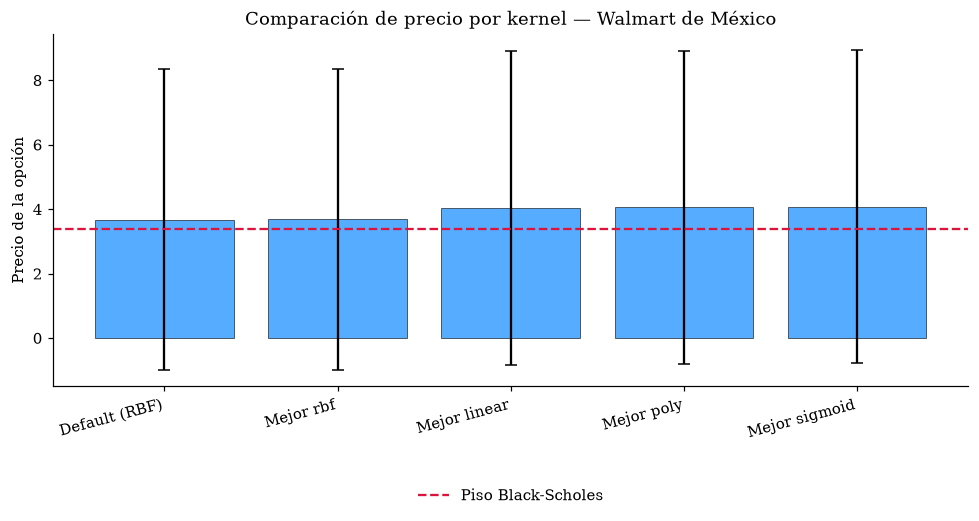

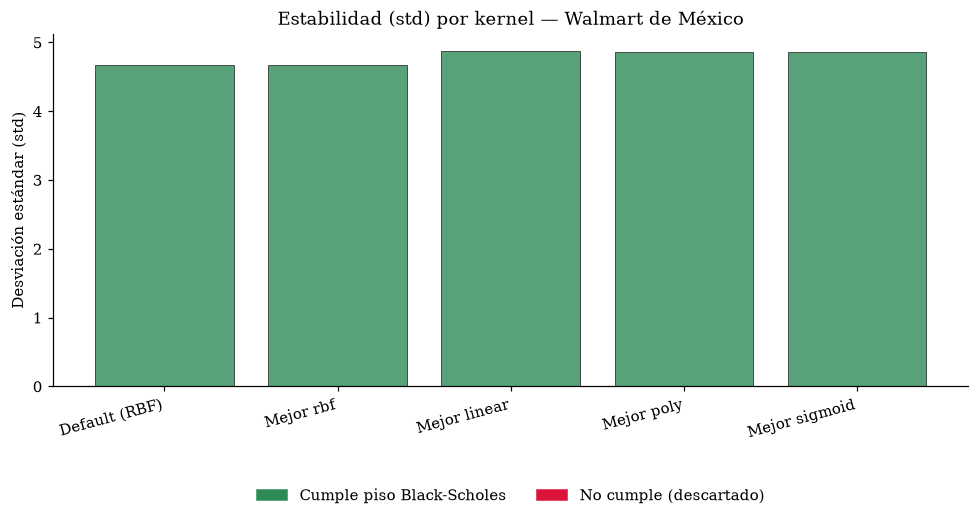

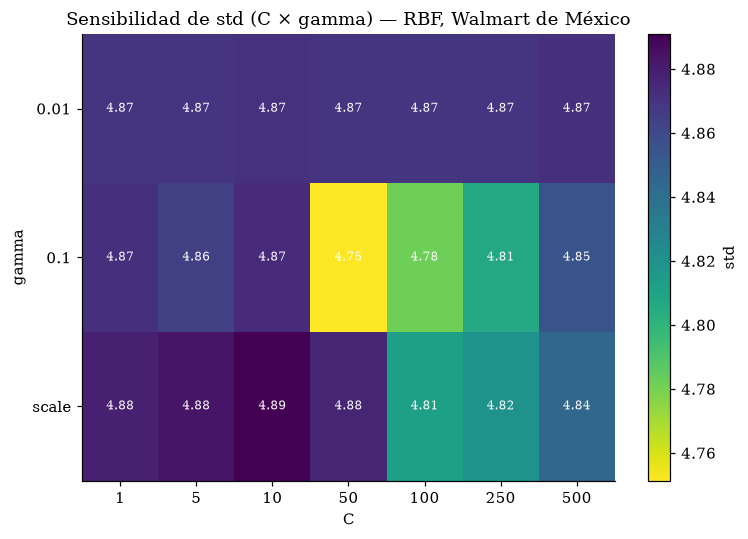

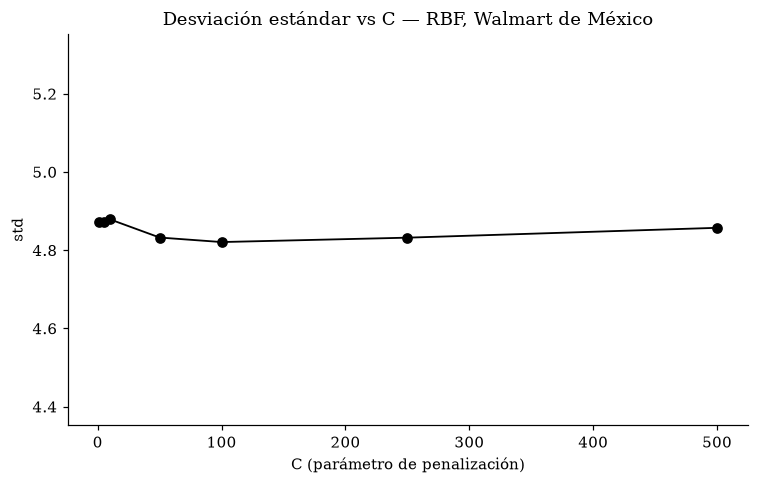

In [24]:
## 17. Sensibilidad a kernel, C, gamma y epsilon

mejor_rbf, tabla_rbf, piso_bs_calib = calibrar_svr(
    TICKERS[0], PARAMS, T, dt, num_paths_calib=1000, seed=SEED,
    kernels=('rbf',),
    C_grid=(1, 5, 10, 50, 100, 250, 500),
    backend=BACKEND
)

mejor_otros, tabla_otros, _ = calibrar_svr(
    TICKERS[0], PARAMS, T, dt, num_paths_calib=1000, seed=SEED,
    kernels=('linear', 'poly', 'sigmoid'),
    C_grid=(10, 50, 100, 500),
    backend=BACKEND
)

# --- Unir ambas mallas en una sola tabla ---
tabla_grid = pd.concat([tabla_rbf, tabla_otros], ignore_index=True)
validos_totales = tabla_grid[tabla_grid['cumple_piso']]
mejor_hparams = (validos_totales if len(validos_totales) > 0 else tabla_grid).sort_values('std').iloc[0].to_dict()

print(f"Piso teórico Black-Scholes (europea): {piso_bs_calib:.4f}")
print(f"Mejor combinación encontrada: {mejor_hparams}")
display(tabla_grid.sort_values('std').head(15))

## 17a. Armar la tabla de casos: default + mejor por kernel

casos = []
res_default = lsm_svr(pol_diag, val_diag, K=PARAMS[TICKERS[0]]['S0'], r=PARAMS[TICKERS[0]]['r'], T=T,
                       kernel=SVR_KERNEL, C=SVR_C, gamma=SVR_GAMMA, epsilon=SVR_EPSILON, backend=BACKEND)
casos.append({'Caso': 'Default (RBF)', 'kernel': SVR_KERNEL, 'C': SVR_C,
              'gamma': SVR_GAMMA, 'epsilon': SVR_EPSILON,
              'precio': res_default['precio'], 'std': res_default['std']})

for kern in tabla_grid['kernel'].unique():
    sub = tabla_grid[tabla_grid['kernel'] == kern]
    validos_k = sub[sub['cumple_piso']]
    mejor_k = (validos_k if len(validos_k) > 0 else sub).sort_values('std').iloc[0]
    casos.append({'Caso': f'Mejor {kern}', 'kernel': mejor_k['kernel'], 'C': mejor_k['C'],
                  'gamma': mejor_k['gamma'], 'epsilon': mejor_k['epsilon'],
                  'precio': mejor_k['precio'], 'std': mejor_k['std']})

df_casos = pd.DataFrame(casos)
df_casos['Piso_BS'] = piso_bs_calib
df_casos['cumple_piso'] = df_casos['precio'] >= piso_bs_calib * 0.98

mejor_caso = (df_casos[df_casos['cumple_piso']] if df_casos['cumple_piso'].any() else df_casos).sort_values('std').iloc[0]
print(f"\n=== Mejor caso general: {mejor_caso['Caso']} (std={mejor_caso['std']:.4f}, precio={mejor_caso['precio']:.4f}) ===")
display(df_casos)

## 17b. Gráfica 1 — Precio por caso, con piso de Black-Scholes



graficar_comparacion_casos(df_casos, piso_bs_calib,
                            f"Comparación de precio por kernel — {EMISORAS[TICKERS[0]]}")

## 17c. Gráfica 2 — Estabilidad (std) por caso, coloreada por validez teórica


graficar_comparacion_std(df_casos, f"Estabilidad (std) por kernel — {EMISORAS[TICKERS[0]]}")

## 17d. Gráfica 3 — Heatmap de sensibilidad C × gamma (kernel RBF)



graficar_heatmap_svr(tabla_grid, kernel='rbf', metric='std',
                     titulo=f'Sensibilidad de std (C × gamma) — RBF, {EMISORAS[TICKERS[0]]}')

## 17e. Gráfica 4 — Curva de error (std) vs hiperparámetro C, aislado

graficar_error_vs_C(tabla_grid, kernel='rbf', metric='std',
                    titulo=f'Desviación estándar vs C — RBF, {EMISORAS[TICKERS[0]]}')

In [ ]:
def graficar_error_vs_C(tabla_grid, kernel='rbf', metric='std', titulo=None):
    sub = tabla_grid[tabla_grid['kernel'] == kernel].copy()
    curva = sub.groupby('C')[metric].mean().reset_index().sort_values('C')

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(curva['C'], curva[metric], 'o-', color='black', markersize=6, lw=1.2)
    ax.set_xlabel('C (parámetro de penalización)')
    ax.set_ylabel(metric)
    ax.set_title(titulo or f'{metric} de validación vs hiperparámetro C — kernel {kernel}')
    # Fuerza un rango más amplio para no exagerar variaciones pequeñas
    centro = curva[metric].mean()
    ax.set_ylim(centro - 0.5, centro + 0.5)  # <-- ajusta el margen a tu gusto
    plt.tight_layout()
    plt.show()

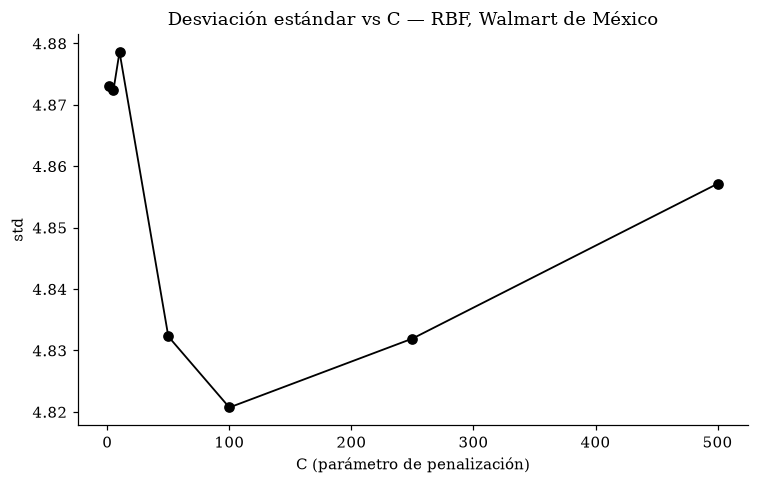

In [26]:

graficar_error_vs_C(tabla_grid, kernel='rbf', metric='std',
                    titulo=f'Desviación estándar vs C — RBF, {EMISORAS[TICKERS[0]]}')

## 18. Validación contra mercado real

Se descargan option chains reales y se comparan los métodos de valuación (con
volatilidad histórica, no implícita, para mantener consistencia metodológica) contra
el precio realmente observado en el mercado (`lastPrice`).


In [ ]:
def obtener_opciones_reales(ticker, iv_max=3.0):
    """Descarga la option chain más próxima y filtra puts ITM razonables."""
    tk_obj = yf.Ticker(ticker)
    vencimientos = tk_obj.options
    if not vencimientos:
        return pd.DataFrame()
    chain = tk_obj.option_chain(vencimientos[0])
    puts = chain.puts.copy()
    puts = puts[(puts['impliedVolatility'] < iv_max) & (puts['inTheMoney'])]
    puts['symbol'] = ticker
    puts['shortDate'] = vencimientos[0]
    return puts


def validar_contra_mercado(ticker, params, T_mercado, dt, num_paths, seed,
                            kernel=SVR_KERNEL, backend=BACKEND):
    p = params[ticker]
    opciones = obtener_opciones_reales(ticker)
    if opciones.empty:
        return pd.DataFrame()

    pol, val = preparar_trayectorias(p['r'], p['sigma'], p['S0'], T_mercado, dt,
                                      num_paths, seed, split_paths=True)

    filas = []
    for _, row in opciones.iterrows():
        K = float(row['strike'])
        res_cls = lsm_clasico(pol, val, K=K, r=p['r'], T=T_mercado)
        res_svr = lsm_svr(pol, val, K=K, r=p['r'], T=T_mercado, kernel=kernel, backend=backend)
        bs = black_scholes_put(p['S0'], K, p['r'], p['sigma'], T_mercado)
        mc = monte_carlo_backward(val, K, p['r'], T_mercado)
        binom = binomial_crr(p['S0'], K, p['r'], p['sigma'], T_mercado)

        filas.append({
            'contractSymbol': row['contractSymbol'], 'strike': K,
            'lastPrice': row['lastPrice'],
            'LSM_Clasico': res_cls['precio'], 'LSM_SVR': res_svr['precio'],
            'Black_Scholes': bs, 'Monte_Carlo': mc, 'Binomial_CRR': binom,
        })

    df_val = pd.DataFrame(filas)
    for col in ['LSM_Clasico', 'LSM_SVR', 'Black_Scholes', 'Monte_Carlo', 'Binomial_CRR']:
        df_val[f'Diff_{col}'] = df_val[col] - df_val['lastPrice']
    return df_val


# Correr solo cuando quieras la validación empírica (requiere conexión a yfinance)
validacion_mercado = {}
for tk in TICKERS:
    try:
        validacion_mercado[tk] = validar_contra_mercado(
            tk, PARAMS, T_mercado=T, dt=dt, num_paths=min(NUM_PATHS, 5000), seed=SEED,
            kernel=SVR_KERNEL, backend=BACKEND
        )
    except Exception as e:
        print(f"No se pudo validar {tk}: {e}")

if TICKERS[0] in validacion_mercado:
    validacion_mercado[TICKERS[0]]


## 19. Exportación de tablas a LaTeX

In [ ]:
def tabla_latex_comparativa(df, ticker, caption=None, label=None):
    columnas = ['moneyness', 'K', 'LSM_Clasico', 'LSM_SVR', 'Black_Scholes',
                'Monte_Carlo', 'Binomial_CRR']
    columnas = [c for c in columnas if c in df.columns]
    cap = caption or f"Comparación de métodos de valuación por moneyness — {EMISORAS[ticker]}"
    lab = label or f"tab:moneyness_{ticker.lower()}"
    return df[columnas].to_latex(index=False, float_format="%.4f",
                                  caption=cap, label=lab)


def tabla_latex_validacion_mercado(df, ticker, caption=None, label=None):
    columnas = ['contractSymbol', 'strike', 'lastPrice', 'LSM_Clasico', 'LSM_SVR',
                'Black_Scholes', 'Monte_Carlo', 'Binomial_CRR']
    columnas = [c for c in columnas if c in df.columns]
    cap = caption or f"Validación contra precios de mercado observados — {EMISORAS[ticker]}"
    lab = label or f"tab:validacion_mercado_{ticker.lower()}"
    return df[columnas].to_latex(index=False, float_format="%.4f",
                                  caption=cap, label=lab)


def tabla_latex_descriptivos(params):
    df_desc = pd.DataFrame(params).T
    return df_desc.to_latex(float_format="%.4f",
                             caption="Estadísticos descriptivos por emisora",
                             label="tab:descriptivos")


# Ejemplo de exportación (imprime el código LaTeX; copiarlo al documento)
print(tabla_latex_comparativa(resultados_moneyness[TICKERS[0]], TICKERS[0]))


\begin{table}
\caption{Comparación de métodos de valuación por moneyness — Apple Inc.}
\label{tab:moneyness_aapl}
\begin{tabular}{rrrrrrr}
\toprule
moneyness & K & LSM_Clasico & LSM_SVR & Black_Scholes & Monte_Carlo & Binomial_CRR \\
\midrule
0.7500 & 426.6267 & 106.6567 & 106.8833 & 102.4332 & 136.1709 & 106.6567 \\
0.8000 & 399.9625 & 79.9925 & 80.1393 & 77.1056 & 109.6506 & 80.0131 \\
0.8500 & 376.4353 & 56.4653 & 56.6726 & 55.9870 & 86.2507 & 57.6954 \\
0.9000 & 355.5222 & 35.5522 & 35.7998 & 38.9991 & 65.4510 & 39.9734 \\
0.9500 & 336.8105 & 16.8405 & 17.1004 & 25.9668 & 46.8412 & 26.4984 \\
1.0000 & 319.9700 & 3.8754 & 4.2428 & 16.4995 & 30.0926 & 16.7807 \\
1.0500 & 304.7333 & 2.1478 & 2.6273 & 10.0060 & 17.8666 & 10.1583 \\
1.1000 & 290.8818 & 1.3489 & 1.7451 & 5.7997 & 10.0890 & 5.8799 \\
1.1500 & 278.2348 & 0.8630 & 1.0619 & 3.2204 & 5.5552 & 3.2558 \\
1.2000 & 266.6417 & 0.4647 & 0.5907 & 1.7180 & 2.8913 & 1.7342 \\
1.2500 & 255.9760 & 0.2907 & 0.3530 & 0.8832 & 1.4260 & 0.8